<a href="https://colab.research.google.com/github/Kaitokidbua/ASEAN_Transport/blob/main/ASEAN_Part1_UrbanScale_Fig.1-6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1. ติดตั้งแพ็กเกจฟอนต์ไทยของระบบ Linux
!apt-get install -y fonts-thai-tlwg

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  fonts-tlwg-garuda fonts-tlwg-garuda-ttf fonts-tlwg-kinnari
  fonts-tlwg-kinnari-ttf fonts-tlwg-laksaman fonts-tlwg-laksaman-ttf
  fonts-tlwg-loma fonts-tlwg-loma-ttf fonts-tlwg-mono fonts-tlwg-mono-ttf
  fonts-tlwg-norasi fonts-tlwg-norasi-ttf fonts-tlwg-purisa
  fonts-tlwg-purisa-ttf fonts-tlwg-sawasdee fonts-tlwg-sawasdee-ttf
  fonts-tlwg-typewriter fonts-tlwg-typewriter-ttf fonts-tlwg-typist
  fonts-tlwg-typist-ttf fonts-tlwg-typo fonts-tlwg-typo-ttf fonts-tlwg-umpush
  fonts-tlwg-umpush-ttf fonts-tlwg-waree fonts-tlwg-waree-ttf
The following NEW packages will be installed:
  fonts-thai-tlwg fonts-tlwg-garuda fonts-tlwg-garuda-ttf fonts-tlwg-kinnari
  fonts-tlwg-kinnari-ttf fonts-tlwg-laksaman fonts-tlwg-laksaman-ttf
  fonts-tlwg-loma fonts-tlwg-loma-ttf fonts-tlwg-mono fonts-tlwg-mono-ttf
  fonts-tlwg-norasi fonts-tlwg-norasi-ttf fo

In [2]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# 1. สั่งให้ Font Manager เพิ่มฟอนต์ Loma เข้าไปในระบบ
fm.fontManager.addfont('/usr/share/fonts/truetype/tlwg/Loma.ttf')

# 2. ตั้งค่า Default ให้ทุกกราฟใช้ฟอนต์ Loma
plt.rcParams['font.family'] = 'Loma'

# 3. แก้ไขปัญหาเครื่องหมายลบ (Minus sign) แสดงผลผิดพลาด
plt.rcParams['axes.unicode_minus'] = False

# ตั้งค่า Style ของ Seaborn อีกครั้งเพื่อให้ Font ติดไปด้วย
sns.set_theme(style="whitegrid", font='Loma')

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ตั้งค่าสไตล์ของกราฟ
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'Loma'

# --- 1. คลีนและเตรียมข้อมูล ---
df = pd.read_csv("ASEAN_Urban_Growth_Final_with_Mode.csv")

# แปลงวันที่
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y', errors='coerce')

# คลีนข้อมูล: ตัดช่วงที่ Ridership เป็น 0 ออก (ถือว่ายังไม่เปิดบริการ)
# เพื่อไม่ให้ตัวหาร (จำนวนวัน) เยอะเกินความจริงจนค่าเฉลี่ยต่ำ
df_active = df[df['Ridership'] > 0].copy()

# คำนวณ Per Capita รายวัน (เพื่อให้สัมพันธ์กับ Population ของปีนั้นๆ)
df_active['Daily_Per_Capita'] = df_active['Ridership'] / (df_active['Population_Million'] * 1_000_000)

# สรุปข้อมูลรายเมือง (ใช้วิธีหาค่าเฉลี่ยรายวันเพื่อแก้ปัญหาจำนวนปีที่มาไม่เท่ากัน)
city_analysis = df_active.groupby(['City', 'Country']).agg({
    'Population_Million': 'last',          # ใช้จำนวนประชากรล่าสุดที่มีใน Dataset
    'Ridership': 'mean',                  # จำนวนผู้โดยสารเฉลี่ยต่อวัน (Daily Avg Volume)
    'Daily_Per_Capita': 'mean'            # utilization เฉลี่ยต่อวัน (Daily Utilization)
}).reset_index()

# เปลี่ยนชื่อ Column ให้สื่อความหมายชัดเจน
city_analysis.columns = ['เมืองหลวง ASEAN', 'ประเทศ', 'Latest_Pop_M', 'Avg_Daily_Ridership', 'Utilization_Index']

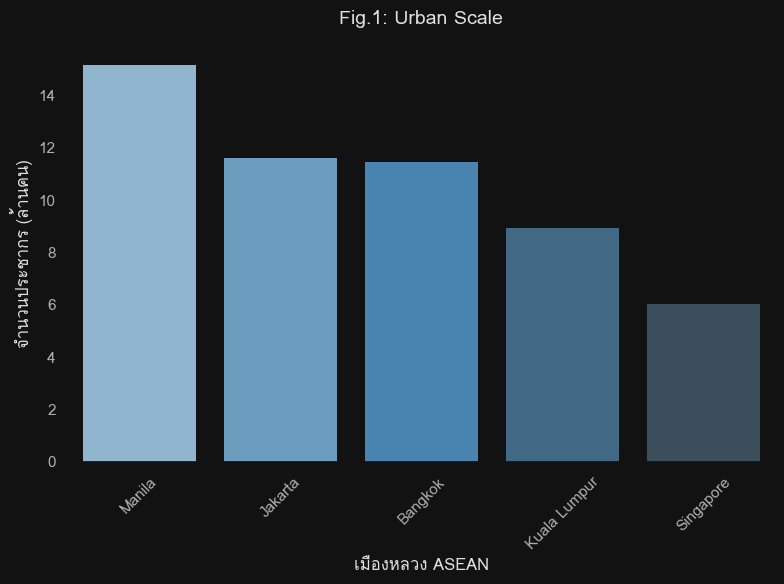

In [4]:
dark_grey = "#121212"
border_grey = "#2C2C2C"

plt.rcParams.update({
    "figure.facecolor": dark_grey,    # พื้นที่รอบนอกกราฟ
    "axes.facecolor": dark_grey,      # พื้นที่ในกราฟ
    "axes.edgecolor": dark_grey,      # เส้นขอบกราฟ (ใช้สีเดียวกับพื้นหลังเพื่อซ่อนขอบ)
    "grid.color": "#2C2C2C",          # ถ้าอยากมีเส้นตารางจางๆ ให้ใช้สีเทาที่สว่างกว่าพื้นหลัง
    "text.color": "#E0E0E0",          # (Off-white) เพื่อลด Contrast
    "axes.labelcolor": "#E0E0E0",
    "xtick.color": "#B0B0B0",         # สีตัวเลขแกน X (เทาอ่อน)
    "ytick.color": "#B0B0B0"          # สีตัวเลขแกน Y (เทาอ่อน)
})

plt.figure(figsize=(8, 6))

# 2. วาดกราฟ
sns.barplot(data=city_analysis.sort_values('Latest_Pop_M', ascending=False),
            x='เมืองหลวง ASEAN', y='Latest_Pop_M', hue='เมืองหลวง ASEAN', palette='Blues_d',
            legend=False, edgecolor='none')

# 3. ใส่ชื่อและปรับแต่ง
plt.title('Fig.1: Urban Scale', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('จำนวนประชากร (ล้านคน)')
plt.xticks(rotation=45)

# 4. ลบเส้นตารางออก (ถ้ามี)
plt.grid(False)

# 5. ใช้ tight_layout เพื่อจัดการพื้นที่
plt.tight_layout()
plt.show()

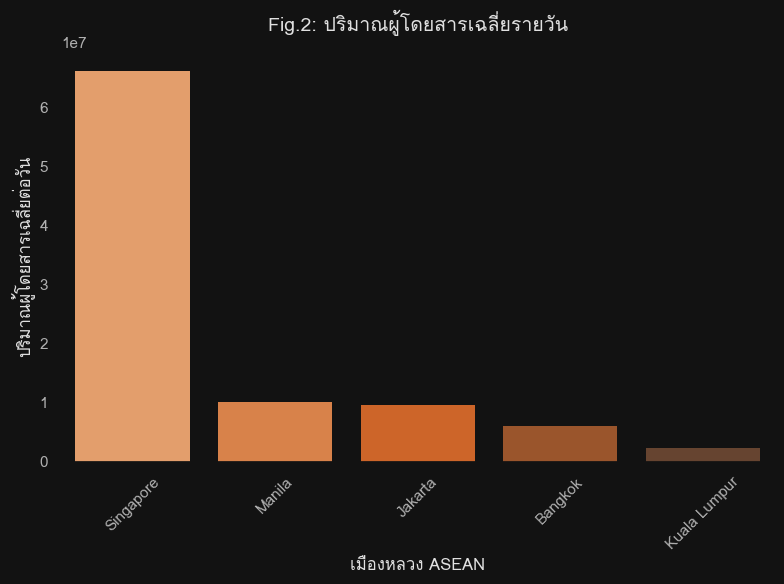

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.rcParams.update({
    "figure.facecolor": dark_grey,    # พื้นที่รอบนอกกราฟ
    "axes.facecolor": dark_grey,      # พื้นที่ในกราฟ
    "axes.edgecolor": dark_grey,      # เส้นขอบกราฟ (ใช้สีเดียวกับพื้นหลังเพื่อซ่อนขอบ)
    "grid.color": "#2C2C2C",          # ถ้าอยากมีเส้นตารางจางๆ ให้ใช้สีเทาที่สว่างกว่าพื้นหลัง
    "text.color": "#E0E0E0",          # (Off-white) เพื่อลด Contrast
    "axes.labelcolor": "#E0E0E0",
    "xtick.color": "#B0B0B0",         # สีตัวเลขแกน X (เทาอ่อน)
    "ytick.color": "#B0B0B0"          # สีตัวเลขแกน Y (เทาอ่อน)
})

plt.figure(figsize=(8, 6))

# 2. วาดกราฟ Ridership
# เพิ่ม edgecolor='none' เพื่อลบขอบขาวรอบแท่งกราฟ
sns.barplot(data=city_analysis.sort_values('Avg_Daily_Ridership', ascending=False),
            x='เมืองหลวง ASEAN', y='Avg_Daily_Ridership', hue='เมืองหลวง ASEAN', palette='Oranges_d',
            legend=False, edgecolor='none')

# 3. ปรับแต่ง Title และ Label
plt.title('Fig.2: ปริมาณผู้โดยสารเฉลี่ยรายวัน', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('ปริมาณผู้โดยสารเฉลี่ยต่อวัน')
plt.xlabel('เมืองหลวง ASEAN')
plt.xticks(rotation=45)

# 4. ปิดการใช้งาน Grid เพื่อความดำสนิท
plt.grid(False)

plt.tight_layout()
plt.show()

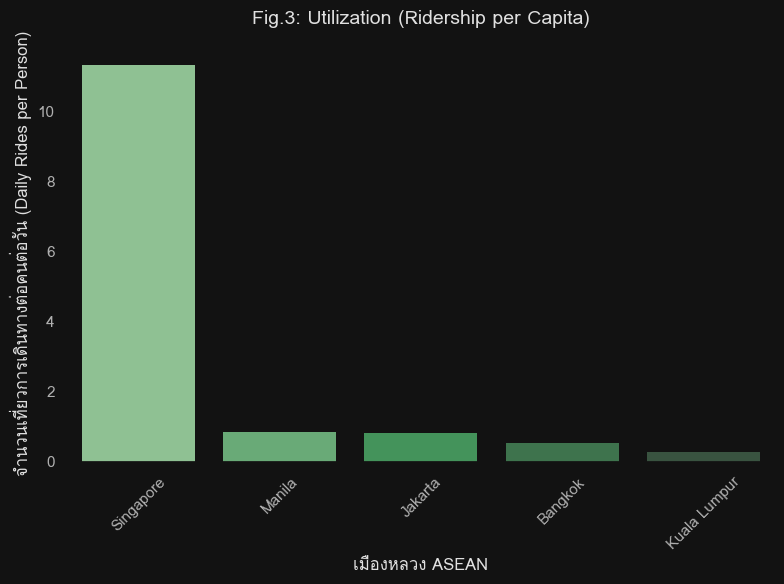

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.rcParams.update({
    "figure.facecolor": dark_grey,    # พื้นที่รอบนอกกราฟ
    "axes.facecolor": dark_grey,      # พื้นที่ในกราฟ
    "axes.edgecolor": dark_grey,      # เส้นขอบกราฟ (ใช้สีเดียวกับพื้นหลังเพื่อซ่อนขอบ)
    "grid.color": "#2C2C2C",          # ถ้าอยากมีเส้นตารางจางๆ ให้ใช้สีเทาที่สว่างกว่าพื้นหลัง
    "text.color": "#E0E0E0",          # (Off-white) เพื่อลด Contrast
    "axes.labelcolor": "#E0E0E0",
    "xtick.color": "#B0B0B0",         # สีตัวเลขแกน X (เทาอ่อน)
    "ytick.color": "#B0B0B0"          # สีตัวเลขแกน Y (เทาอ่อน)
})

plt.figure(figsize=(8, 6))

# 2. วาดกราฟ Efficiency (Utilization_Index)
# เพิ่ม edgecolor='none' เพื่อลบขอบสีขาวรอบแท่งกราฟออก
sns.barplot(data=city_analysis.sort_values('Utilization_Index', ascending=False),
            x='เมืองหลวง ASEAN', y='Utilization_Index', hue='เมืองหลวง ASEAN', palette='Greens_d',
            legend=False, edgecolor='none')

# 3. ปรับแต่ง Title และ Label
# ปรับเป็น Fig.29 เพื่อให้เรียงต่อจากอันก่อนหน้า
plt.title('Fig.3: Utilization (Ridership per Capita)', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('จำนวนเที่ยวการเดินทางต่อคนต่อวัน (Daily Rides per Person)')
plt.xlabel('เมืองหลวง ASEAN')
plt.xticks(rotation=45)

# 4. ปิดการใช้งาน Grid และจัดการ Layout
plt.grid(False)
plt.tight_layout()

plt.show()

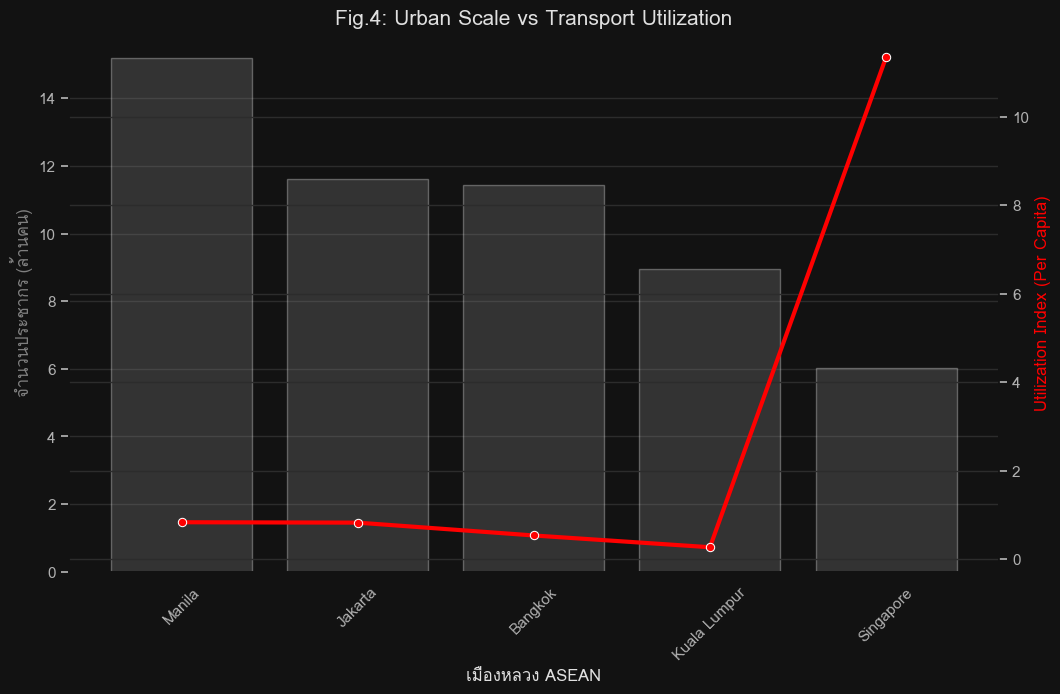

In [15]:
# ส่วนที่ 2: Dual Axis Chart (Scale vs Utilization)

plt.rcParams.update({
    "figure.facecolor": dark_grey,    # พื้นที่รอบนอกกราฟ
    "axes.facecolor": dark_grey,      # พื้นที่ในกราฟ
    "axes.edgecolor": dark_grey,      # เส้นขอบกราฟ (ใช้สีเดียวกับพื้นหลังเพื่อซ่อนขอบ)
    "grid.color": "#2C2C2C",          # ถ้าอยากมีเส้นตารางจางๆ ให้ใช้สีเทาที่สว่างกว่าพื้นหลัง
    "text.color": "#E0E0E0",          # (Off-white) เพื่อลด Contrast
    "axes.labelcolor": "#E0E0E0",
    "xtick.color": "#B0B0B0",         # สีตัวเลขแกน X (เทาอ่อน)
    "ytick.color": "#B0B0B0"          # สีตัวเลขแกน Y (เทาอ่อน)
})

fig, ax1 = plt.subplots(figsize=(12, 7))

# แกน 1: ขนาดประชากร (Bar)
sns.barplot(data=city_analysis.sort_values('Latest_Pop_M', ascending=False),
            x='เมืองหลวง ASEAN', y='Latest_Pop_M', alpha=0.3, color='gray', ax=ax1)
ax1.set_ylabel('จำนวนประชากร (ล้านคน)', color='gray', fontsize=12)

# แกน 2: ประสิทธิภาพ (Line)
ax2 = ax1.twinx()
sns.lineplot(data=city_analysis.sort_values('Latest_Pop_M', ascending=False),
             x='เมืองหลวง ASEAN', y='Utilization_Index', marker='o', color='red', linewidth=3, ax=ax2)
ax2.set_ylabel('Utilization Index (Per Capita)', color='red', fontsize=12)

plt.title('Fig.4: Urban Scale vs Transport Utilization', fontsize=15)
ax1.tick_params(axis='x', rotation=45)
plt.show()

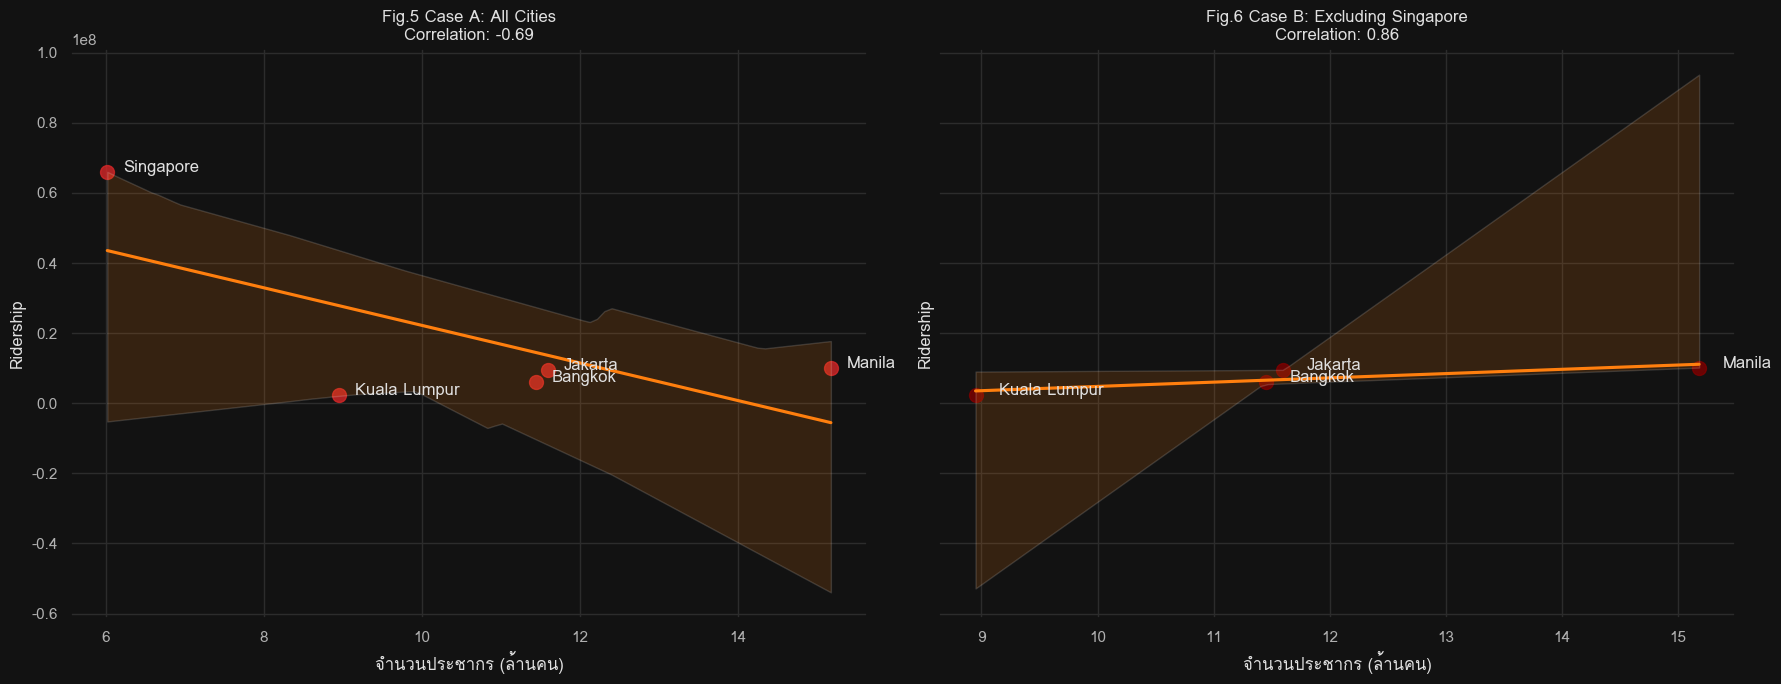

In [12]:
# 1. เตรียมข้อมูล
df = pd.read_csv("ASEAN_Urban_Growth_Final_with_Mode.csv")
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y', errors='coerce')
df_active = df[df['Ridership'] > 0].copy()

df_active['Daily_Per_Capita'] = df_active['Ridership'] / (df_active['Population_Million'] * 1_000_000)

city_analysis = df_active.groupby(['City', 'Country']).agg({
    'Population_Million': 'last',
    'Ridership': 'mean',
    'Daily_Per_Capita': 'mean',
    'GDP_Billion_USD': 'last' # เพิ่ม GDP เข้ามาวิเคราะห์
}).reset_index()

# 2. สร้าง Subsets: รวม SG vs ตัด SG
all_cities = city_analysis.copy()
exclude_sg = city_analysis[city_analysis['Country'] != 'Singapore'].copy()

# 3. Visualization: Comparative Correlation ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

# กราฟแรก: รวมทุกเมือง
sns.regplot(data=all_cities, x='Population_Million', y='Ridership', ax=ax1,
            scatter_kws={'s':100, 'color':'#d62728'}, line_kws={'color':'#ff7f0e'})
ax1.set_title(f"Fig.5 Case A: All Cities\nCorrelation: {all_cities['Population_Million'].corr(all_cities['Ridership']):.2f}")

# --- เพิ่มบรรทัดนี้เพื่อเปลี่ยนชื่อแกน X ของกราฟที่ 1 ---
ax1.set_xlabel('จำนวนประชากร (ล้านคน)')


# กราฟสอง: ตัดสิงคโปร์ออก
sns.regplot(data=exclude_sg, x='Population_Million', y='Ridership', ax=ax2,
            scatter_kws={'s':100, 'color':'#800000'}, line_kws={'color':'#ff7f0e'})
ax2.set_title(f"Fig.6 Case B: Excluding Singapore\nCorrelation: {exclude_sg['Population_Million'].corr(exclude_sg['Ridership']):.2f}")

# --- เพิ่มบรรทัดนี้เพื่อเปลี่ยนชื่อแกน X ของกราฟที่ 2 ---
ax2.set_xlabel('จำนวนประชากร (ล้านคน)')

# ใส่ชื่อเมือง (Annotation)
for df_sub, ax in zip([all_cities, exclude_sg], [ax1, ax2]):
    for i, txt in enumerate(df_sub['City']):
        ax.annotate(txt, (df_sub['Population_Million'].iloc[i]+0.2, df_sub['Ridership'].iloc[i]))

plt.tight_layout()
plt.show()